## analysing subtropical cells and their projected changes under different scenarios

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [5]:
# plt.style.use('dark_background')

### Functions needed for the analysis

In [7]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = 'horizontal', shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [8]:
from functions import preproc_funcs as funcs

In [9]:
from functions import xr_lowess

In [9]:
test_hist = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/msftbarot/gn/latest/*.nc', use_cftime=True)
test_ssp = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO/ACCESS-ESM1-5/ssp585/r10i1p1f1/Omon/msftbarot/gn/latest/*.nc', use_cftime=True)

In [10]:
test1_hist = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/msftmz/gn/latest/*.nc', use_cftime=True)
test1_ssp = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO/ACCESS-ESM1-5/ssp585/r10i1p1f1/Omon/msftmz/gn/latest/*.nc', use_cftime=True)

In [11]:
test = xr.concat([test_hist, test_ssp], dim='time')
test

<xarray.Dataset>
Dimensions:             (time: 5412, bnds: 2, j: 300, i: 360, vertices: 4)
Coordinates:
  * time                (time) object 1850-01-16 12:00:00 ... 2300-12-16 12:0...
  * j                   (j) int32 0 1 2 3 4 5 6 ... 293 294 295 296 297 298 299
  * i                   (i) int32 0 1 2 3 4 5 6 ... 353 354 355 356 357 358 359
    latitude            (j, i) float64 -77.88 -77.88 -77.88 ... 65.63 65.21
    longitude           (j, i) float64 81.0 82.0 83.0 84.0 ... 80.0 80.0 80.0
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) object dask.array<chunksize=(1980, 2), meta=np.ndarray>
    vertices_latitude   (j, i, vertices, time) float64 dask.array<chunksize=(300, 360, 4, 1980), meta=np.ndarray>
    vertices_longitude  (j, i, vertices, time) float64 dask.array<chunksize=(300, 360, 4, 1980), meta=np.ndarray>
    msftbarot           (time, j, i) float32 dask.array<chunksize=(1980, 300, 360), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    creation_date:          2020-06-05T05:00:56Z
    ...                     ...
    variable_id:            msftbarot
    variant_label:          r10i1p1f1
    version:                v20200605
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/6f4c7e5e-bbb0-4b73-ae21-8f042c97c526

In [12]:
test1 = xr.concat([test1_hist, test1_ssp], dim='time')
test1

<xarray.Dataset>
Dimensions:    (time: 5412, bnds: 2, basin: 3, lev: 50, lat: 300)
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2300-12-16 12:00:00
    sector     (basin) |S21 b'atlantic_arctic_ocean' ... b'global_ocean'
  * lev        (lev) float64 5.0 15.0 25.0 ... 5.166e+03 5.499e+03 5.831e+03
  * lat        (lat) float64 -77.75 -77.51 -77.26 -77.01 ... 89.1 89.55 90.0
Dimensions without coordinates: bnds, basin
Data variables:
    time_bnds  (time, bnds) object dask.array<chunksize=(120, 2), meta=np.ndarray>
    lev_bnds   (time, lev, bnds) float64 dask.array<chunksize=(120, 50, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 dask.array<chunksize=(120, 300, 2), meta=np.ndarray>
    msftmz     (time, basin, lev, lat) float32 dask.array<chunksize=(120, 3, 50, 300), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    creation_date:          2020-06-05T05:09:38Z
    ...                     ...
    variable_id:            msftmz
    variant_label:          r10i1p1f1
    version:                v20200605
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/ff816ada-8da0-48e2-bd8d-678e70e77852

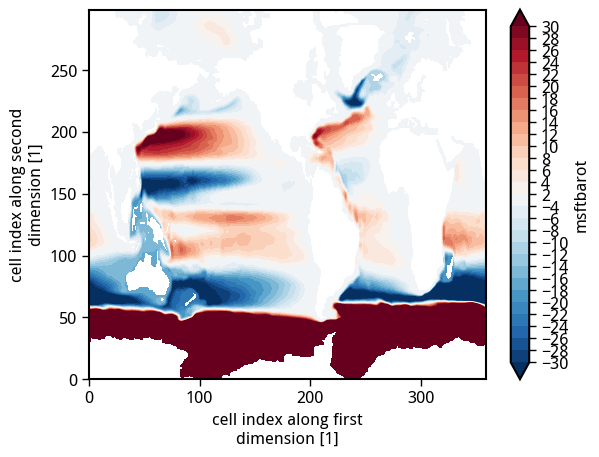

In [13]:
levels_min = np.arange(-30, -2, 2)
levels_max = np.arange(2, 32, 2)
levels = np.append(levels_min, levels_max)
# levels
(test.msftbarot.sel(time = slice('2000', '2010')).mean('time')/10**9).plot.contourf(levels=levels, extend='both', cbar_kwargs=dict(ticks=levels))

In [14]:
import xesmf as xe

In [15]:
test1

<xarray.Dataset>
Dimensions:    (time: 5412, bnds: 2, basin: 3, lev: 50, lat: 300)
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2300-12-16 12:00:00
    sector     (basin) |S21 b'atlantic_arctic_ocean' ... b'global_ocean'
  * lev        (lev) float64 5.0 15.0 25.0 ... 5.166e+03 5.499e+03 5.831e+03
  * lat        (lat) float64 -77.75 -77.51 -77.26 -77.01 ... 89.1 89.55 90.0
Dimensions without coordinates: bnds, basin
Data variables:
    time_bnds  (time, bnds) object dask.array<chunksize=(120, 2), meta=np.ndarray>
    lev_bnds   (time, lev, bnds) float64 dask.array<chunksize=(120, 50, 2), meta=np.ndarray>
    lat_bnds   (time, lat, bnds) float64 dask.array<chunksize=(120, 300, 2), meta=np.ndarray>
    msftmz     (time, basin, lev, lat) float32 dask.array<chunksize=(120, 3, 50, 300), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    creation_date:          2020-06-05T05:09:38Z
    ...                     ...
    variable_id:            msftmz
    variant_label:          r10i1p1f1
    version:                v20200605
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/ff816ada-8da0-48e2-bd8d-678e70e77852

In [16]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset>
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
    latitude_longitude  float64 nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 -90.0 -88.5 -88.5 ... 88.5 90.0

In [17]:
msftbarot_trans = test.msftbarot.load()

In [18]:
msftmz_trans = test1.msftmz.load()

In [19]:
regridder = xe.Regridder(msftbarot_trans, ds_out, 'bilinear', periodic=True)

In [20]:
test_regrid = regridder(msftbarot_trans)

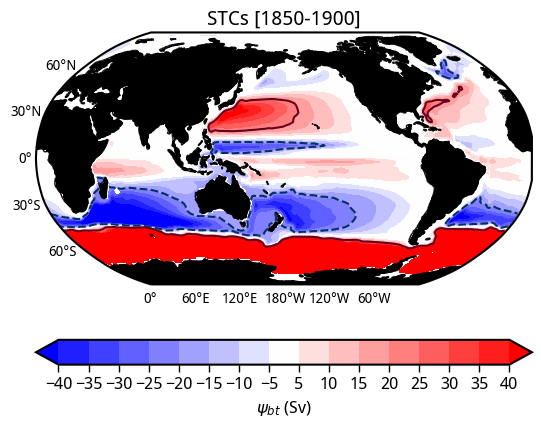

In [32]:
levels_min = np.arange(-40, 0, 5)
levels_max = np.arange(5, 45, 5)
levels = np.append(levels_min, levels_max)
# levels
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
(test_regrid.sel(time = slice('1850', '1900')).mean('time')/10**9).plot.contourf(levels=levels, extend='both', cbar_kwargs=dict(ticks=levels, orientation='horizontal', label = '$\psi_{bt}$ (Sv)'), robust=True, transform=ccrs.PlateCarree(), cmap='bwr')
(test_regrid.sel(time = slice('1850', '1900')).mean('time')/10**9).plot.contour(levels=[-20, 20], extend='both', ls='-', robust=True, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k')
plot_background(ax)
ax.set_title('STCs [1850-1900]')
plt.savefig('./images/ocean_transport/access_r10_barot_pi.png', dpi=300, bbox_inches='tight')

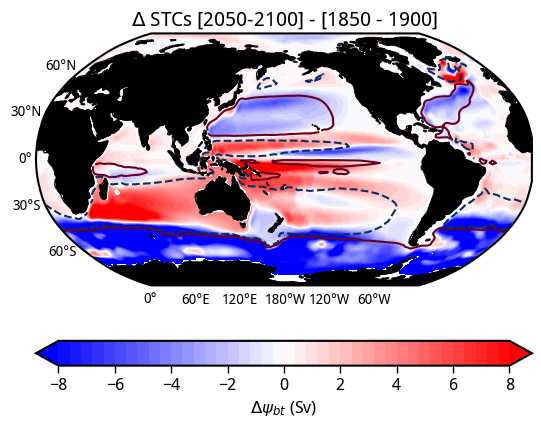

In [33]:
levels = np.arange(-8, 8.4, 0.4)
diff =  (test_regrid.sel(time = slice('2050', '2100')).mean('time')/10**9) - (test_regrid.sel(time = slice('1850', '1900')).mean('time')/10**9)
# levels
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
(diff).plot.contourf(levels=levels, extend='both', cbar_kwargs=dict(orientation='horizontal', label='$\Delta\psi_{bt}$ (Sv)'), robust=True, transform=ccrs.PlateCarree(), cmap='bwr')
(test_regrid.sel(time = slice('1850', '1900')).mean('time')/10**9).plot.contour(levels=[-10, 10], extend='both', ls='-', robust=True, transform=ccrs.PlateCarree(), alpha=1.0)
ax.add_feature(cfeature.LAND, color='k')
plot_background(ax)
ax.set_title('$\Delta$ STCs [2050-2100] - [1850 - 1900]')
plt.savefig('./images/ocean_transport/access_r10_barot_change.png', dpi=300, bbox_inches='tight')

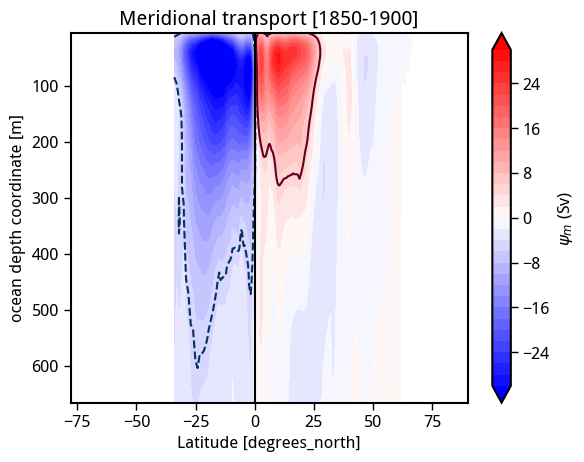

In [34]:
(test1.msftmz.isel(basin=1).sel(time = slice('1850', '1900'), lev=slice(0, 800)).mean('time')/10**9).plot.contourf(levels=np.arange(-30, 32, 2), extend='both', cmap='bwr', cbar_kwargs = dict(label = '$\psi_m$ (Sv)'))
(test1.msftmz.isel(basin=1).sel(time = slice('1850', '1900'), lev=slice(0, 800)).mean('time')/10**9).plot.contour(levels=[-5, 5], extend='both')
plt.gca().invert_yaxis()
plt.axvline(0.0, color='k')
plt.title('Meridional transport [1850-1900]')
plt.savefig('./images/ocean_transport/access_r10_merid_indopacific_pi.png', dpi=300, bbox_inches='tight')

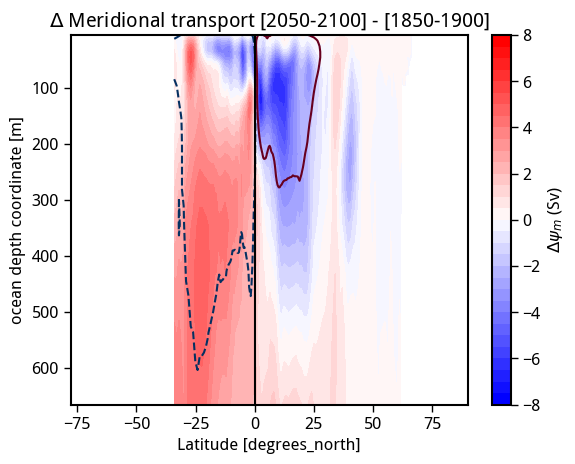

In [35]:
diff = ((test1.msftmz.isel(basin=1).sel(time = slice('2050', '2100'), lev=slice(0, 800)).mean('time')/10**9)  - (test1.msftmz.isel(basin=1).sel(time = slice('1850', '1900'), lev=slice(0, 800)).mean('time')/10**9))

(diff).plot.contourf(levels=np.arange(-8, 8.5, 0.5), cmap='bwr', cbar_kwargs=dict(label='$\Delta\psi_m$ (Sv)'))
(test1.msftmz.isel(basin=1).sel(time = slice('1850', '1900'), lev=slice(0, 800)).mean('time')/10**9).plot.contour(levels=[-5, 5], extend='both')
plt.gca().invert_yaxis()
plt.axvline(0.0, color='k')
plt.title('$\Delta$ Meridional transport [2050-2100] - [1850-1900]')
plt.savefig('./images/ocean_transport/access_r10_merid_indopacific_change.png', dpi=300, bbox_inches='tight')

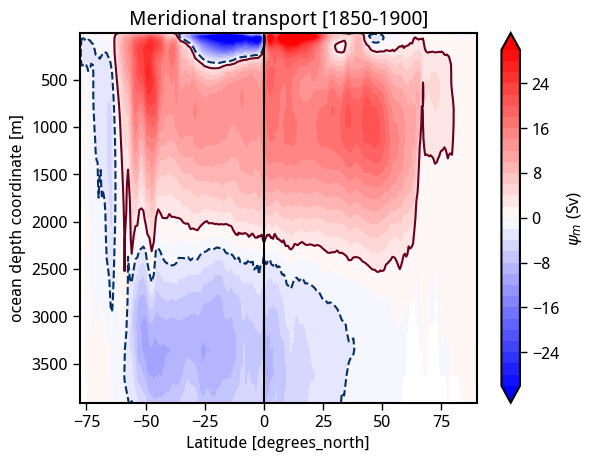

In [36]:
(test1.msftmz.isel(basin=2).sel(time = slice('1850', '1900'), lev=slice(0, 4000)).mean('time')/10**9).plot.contourf(levels=np.arange(-30, 32, 2), cmap='bwr', cbar_kwargs = dict(label = '$\psi_m$ (Sv)'))
(test1.msftmz.isel(basin=2).sel(time = slice('1850', '1900'), lev=slice(0, 4000)).mean('time')/10**9).plot.contour(levels=[-2, 2])
plt.gca().invert_yaxis()
plt.axvline(0.0, color='k')
plt.title('Meridional transport [1850-1900]')
plt.savefig('./images/ocean_transport/access_r10_merid_global_pi.png', dpi=300, bbox_inches='tight')

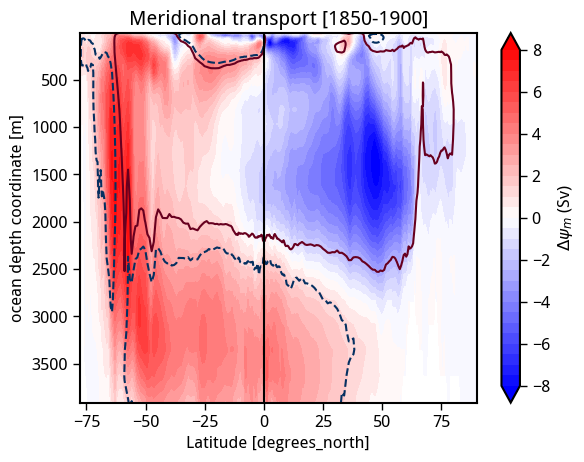

In [37]:
diff1 = ((test1.msftmz.isel(basin=2).sel(time = slice('2050', '2100'), lev=slice(0,4000)).mean('time')/10**9)  - (test1.msftmz.isel(basin=2).sel(time = slice('1850', '1900'), lev=slice(0,4000)).mean('time')/10**9))
(diff1).plot.contourf(levels=np.arange(-8, 8.5, 0.5), extend='both', cmap='bwr', cbar_kwargs=dict(label='$\Delta\psi_m$ (Sv)'))
(test1.msftmz.isel(basin=2).sel(time = slice('1850', '1900'), lev=slice(0, 4000)).mean('time')/10**9).plot.contour(levels=[-2, 2])
plt.gca().invert_yaxis()
plt.axvline(0.0, color='k')
plt.title('Meridional transport [1850-1900]')
plt.savefig('./images/ocean_transport/access_r10_merid_global_change.png', dpi=300, bbox_inches='tight')

In [87]:
test2 = xc.open_mfdataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/thetao/gn/latest/*.nc', parallel=True)

In [86]:
test3 = xc.open_mfdataset('/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO/ACCESS-ESM1-5/ssp585/r10i1p1f1/Omon/thetao/gn/latest/*.nc', parallel=True)

In [88]:
test2

<xarray.Dataset>
Dimensions:             (time: 1980, bnds: 2, lev: 50, j: 300, i: 360,
                         vertices: 4)
Coordinates:
  * time                (time) object 1850-01-16 12:00:00 ... 2014-12-16 12:0...
  * lev                 (lev) float64 5.0 15.0 25.0 ... 5.499e+03 5.831e+03
  * j                   (j) int32 0 1 2 3 4 5 6 ... 293 294 295 296 297 298 299
  * i                   (i) int32 0 1 2 3 4 5 6 ... 353 354 355 356 357 358 359
    latitude            (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude           (j, i) float64 dask.array<chunksize=(300, 360), meta=np.ndarray>
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) object dask.array<chunksize=(120, 2), meta=np.ndarray>
    lev_bnds            (lev, bnds) float64 dask.array<chunksize=(50, 2), meta=np.ndarray>
    vertices_latitude   (j, i, vertices) float64 dask.array<chunksize=(300, 360, 4), meta=np.ndarray>
    vertices_longitude  (j, i, vertices) float64 dask.array<chunksize=(300, 360, 4), meta=np.ndarray>
    thetao              (time, lev, j, i) float32 dask.array<chunksize=(120, 50, 300, 360), meta=np.ndarray>
    i_bnds              (i, bnds) float64 -0.5 0.5 0.5 1.5 ... 358.5 358.5 359.5
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  87658.0
    creation_date:          2020-06-05T04:54:23Z
    ...                     ...
    variable_id:            thetao
    variant_label:          r10i1p1f1
    version:                v20200605
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/54af9cb6-a323-46aa-a8e3-1d5231ab8b42

In [89]:
lll = test2.thetao.sel(time = slice('1850', '1900'), j = slice(140, 160), i = slice(20, 200), lev=slice(0, 3000)).mean(('time', 'j'))
lll_fut = test3.thetao.sel(time = slice('2050', '2100'), j = slice(140, 160), i = slice(20, 200), lev=slice(0, 3000)).mean(('time', 'j'))

In [90]:
from dask.diagnostics import ProgressBar

In [91]:
with ProgressBar():
    lll_loaded = lll.compute()

[########################################] | 100% Completed | 92.55 s


In [92]:
with ProgressBar():
    lll_fut_loaded = lll_fut.compute()

[                                        ] | 0% Completed | 342.80 us[########################################] | 100% Completed | 99.62 s


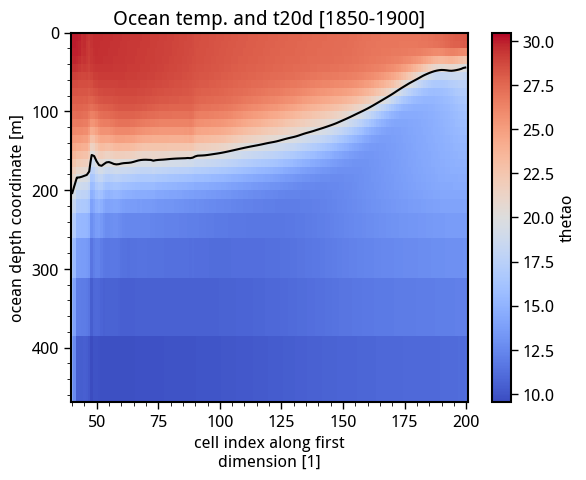

In [112]:
lll_loaded.sel(i = slice(40, 200), lev=slice(0, 500)).plot(cmap='coolwarm', center=20)
lll_loaded.sel(i = slice(40, 200)).plot.contour(colors='k', levels=[20])
# plt.ylim(0, 1000)
plt.gca().invert_yaxis()
plt.title('Ocean temp. and t20d [1850-1900]')
plt.minorticks_on()
plt.savefig('./images/ocean_transport/access_r10_t20d_pi.png', dpi=300, bbox_inches='tight')

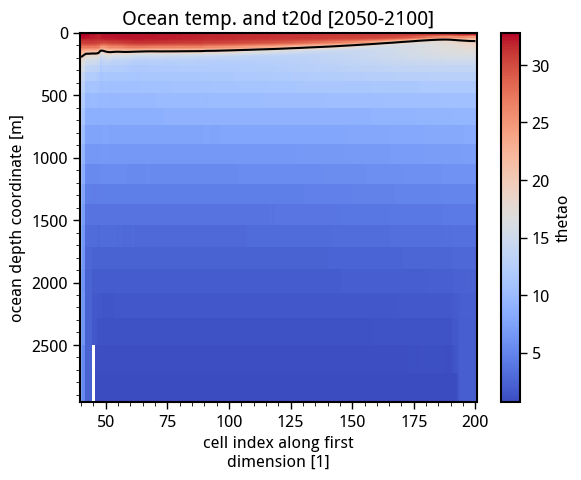

In [97]:
lll_fut_loaded.sel(i = slice(40, 200)).plot(cmap='coolwarm')
lll_fut_loaded.sel(i = slice(40, 200)).plot.contour(colors='k', levels=[20])
# plt.ylim(0, 1000)
plt.gca().invert_yaxis()
plt.title('Ocean temp. and t20d [2050-2100]')
plt.minorticks_on()
plt.savefig('./images/ocean_transport/access_r10_t20d_future.png', dpi=300, bbox_inches='tight')

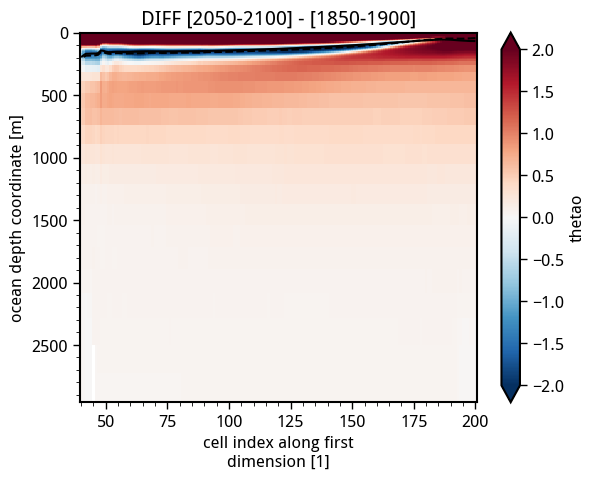

In [106]:
(lll_fut_loaded - lll_loaded).sel(i = slice(40, 200)).plot(cmap='RdBu_r', vmin=-2.0)
lll_loaded.sel(i = slice(40, 200)).plot.contour(colors='k', linestyles='--', levels=[20])
lll_fut_loaded.sel(i = slice(40, 200)).plot.contour(colors='k', levels=[20])
# plt.ylim(0, 1000)
plt.gca().invert_yaxis()
plt.minorticks_on()
plt.title('DIFF [2050-2100] - [1850-1900]')
plt.savefig('./images/ocean_transport/access_r10_t20d_change.png', dpi=300, bbox_inches='tight')

In [41]:
test5 = xr.open_dataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/htovovrt/gn/latest/htovovrt_Omon_ACCESS-ESM1-5_historical_r10i1p1f1_gn_185001-201412.nc')
test6 = xr.open_dataset('/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO/ACCESS-ESM1-5/ssp585/r10i1p1f1/Omon/htovovrt/gn/latest/htovovrt_Omon_ACCESS-ESM1-5_ssp585_r10i1p1f1_gn_201501-210012.nc')

In [42]:
test5.htovovrt

<xarray.DataArray 'htovovrt' (time: 1980, basin: 3, lat: 300)>
[1782000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
    sector   (basin) |S21 ...
  * lat      (lat) float64 -77.75 -77.51 -77.26 -77.01 ... 88.65 89.1 89.55 90.0
Dimensions without coordinates: basin
Attributes:
    standard_name:  northward_ocean_heat_transport_due_to_overturning
    long_name:      Northward Ocean Heat Transport Due to Overturning
    comment:        From all advective mass transport processes, resolved and...
    units:          W
    cell_methods:   longitude: sum (comment: basin sum [along zig-zag grid pa...
    history:        2020-06-05T05:12:13Z altered by CMOR: Reordered dimension...

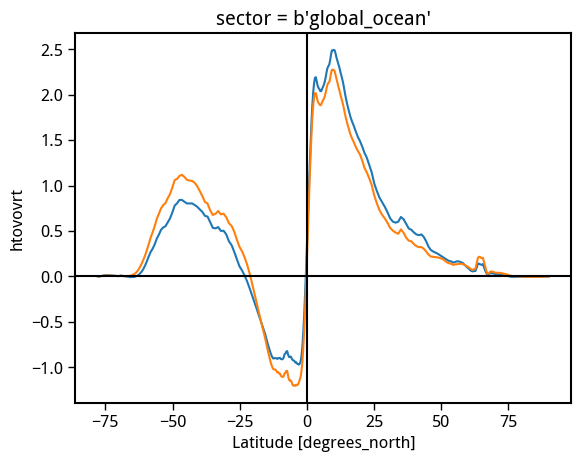

In [60]:
(test5.htovovrt/10**15).sel(time = slice('1850', '1900')).mean('time').isel(basin=2).plot()
(test6.htovovrt/10**15).sel(time = slice('2050', '2100')).mean('time').isel(basin=2).plot()
plt.axhline(0.0, color='k')
plt.axvline(0.0, color='k')

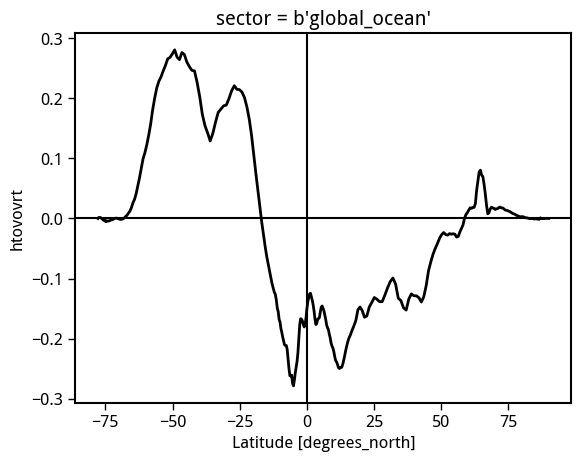

In [61]:
((test6.htovovrt.sel(time = slice('2050', '2100')).mean('time').isel(basin=2) - test5.htovovrt.sel(time = slice('1850', '1900')).mean('time').isel(basin=2))/10**15).plot(lw=2.0, color='k')
plt.axhline(0.0, color='k')
plt.axvline(0.0, color='k')

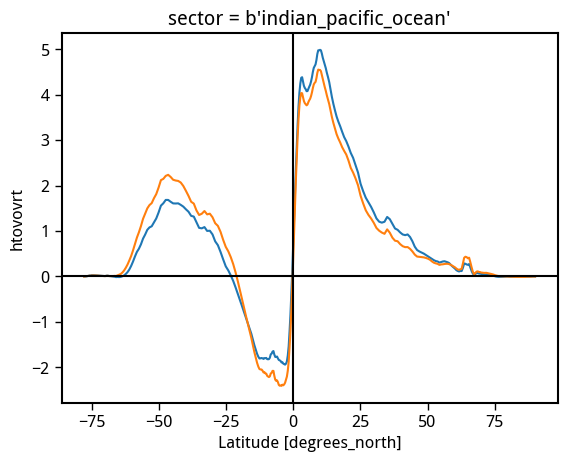

In [62]:
(test5.htovovrt/10**15).sel(time = slice('1850', '1900')).mean('time').isel(basin=1).plot()
(test6.htovovrt/10**15).sel(time = slice('2050', '2100')).mean('time').isel(basin=1).plot()
plt.axhline(0.0, color='k')
plt.axvline(0.0, color='k')

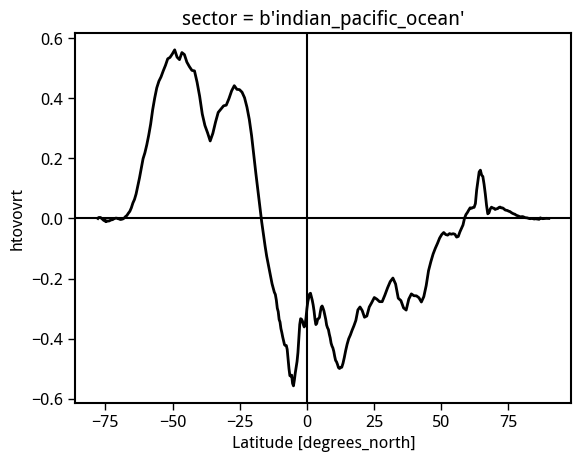

In [63]:
((test6.htovovrt.sel(time = slice('2050', '2100')).mean('time').isel(basin=1) - test5.htovovrt.sel(time = slice('1850', '1900')).mean('time').isel(basin=1))/10**15).plot(lw=2.0, color='k')
plt.axhline(0.0, color='k')
plt.axvline(0.0, color='k')

In [64]:
test5 = xr.open_dataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/htovgyre/gn/latest/htovgyre_Omon_ACCESS-ESM1-5_historical_r10i1p1f1_gn_185001-201412.nc')
test6 = xr.open_dataset('/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO/ACCESS-ESM1-5/ssp585/r10i1p1f1/Omon/htovgyre/gn/latest/htovgyre_Omon_ACCESS-ESM1-5_ssp585_r10i1p1f1_gn_201501-210012.nc')

In [65]:
test5.htovgyre

<xarray.DataArray 'htovgyre' (time: 1980, basin: 3, lat: 300)>
[1782000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
    sector   (basin) |S21 ...
  * lat      (lat) float64 -77.75 -77.51 -77.26 -77.01 ... 88.65 89.1 89.55 90.0
Dimensions without coordinates: basin
Attributes:
    standard_name:  northward_ocean_heat_transport_due_to_gyre
    long_name:      Northward Ocean Heat Transport Due to Gyre
    comment:        From all advective mass transport processes, resolved and...
    units:          W
    cell_methods:   longitude: sum (comment: basin sum [along zig-zag grid pa...
    history:        2020-06-05T05:11:31Z altered by CMOR: Reordered dimension...

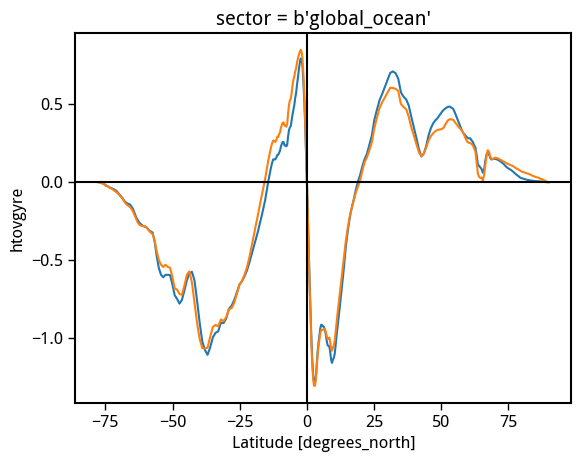

In [66]:
(test5.htovgyre/10**15).sel(time = slice('1850', '1900')).mean('time').isel(basin=2).plot()
(test6.htovgyre/10**15).sel(time = slice('2050', '2100')).mean('time').isel(basin=2).plot()
plt.axhline(0.0, color='k')
plt.axvline(0.0, color='k')

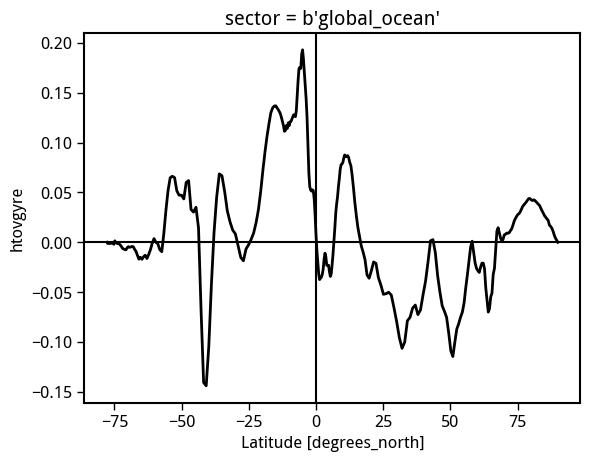

In [67]:
((test6.htovgyre.sel(time = slice('2050', '2100')).mean('time').isel(basin=2) - test5.htovgyre.sel(time = slice('1850', '1900')).mean('time').isel(basin=2))/10**15).plot(lw=2.0, color='k')
plt.axhline(0.0, color='k')
plt.axvline(0.0, color='k')

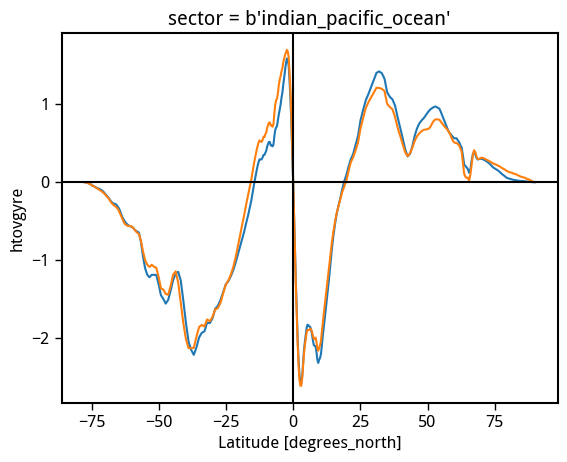

In [68]:
(test5.htovgyre/10**15).sel(time = slice('1850', '1900')).mean('time').isel(basin=1).plot()
(test6.htovgyre/10**15).sel(time = slice('2050', '2100')).mean('time').isel(basin=1).plot()
plt.axhline(0.0, color='k')
plt.axvline(0.0, color='k')

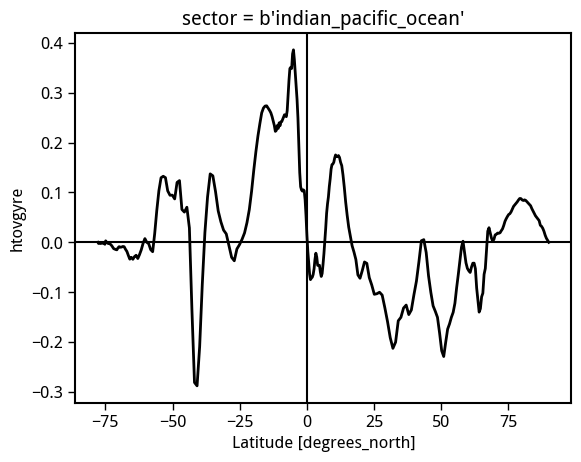

In [69]:
((test6.htovgyre.sel(time = slice('2050', '2100')).mean('time').isel(basin=1) - test5.htovgyre.sel(time = slice('1850', '1900')).mean('time').isel(basin=1))/10**15).plot(lw=2.0, color='k')
plt.axhline(0.0, color='k')
plt.axvline(0.0, color='k')